<a href="https://colab.research.google.com/github/jainpalak1406-cpu/Design-and-Analysis-of-Algorithms-Lab/blob/main/DAA3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

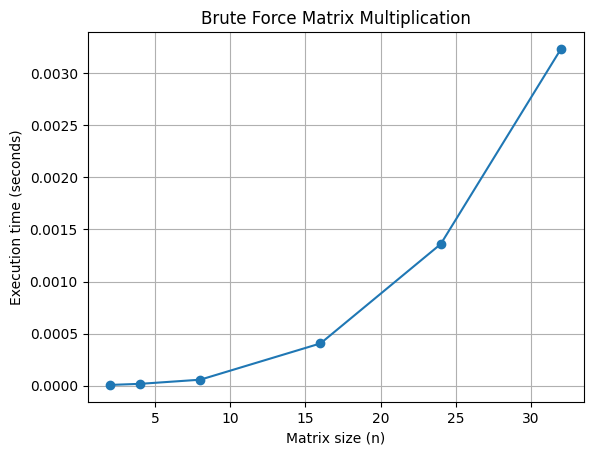

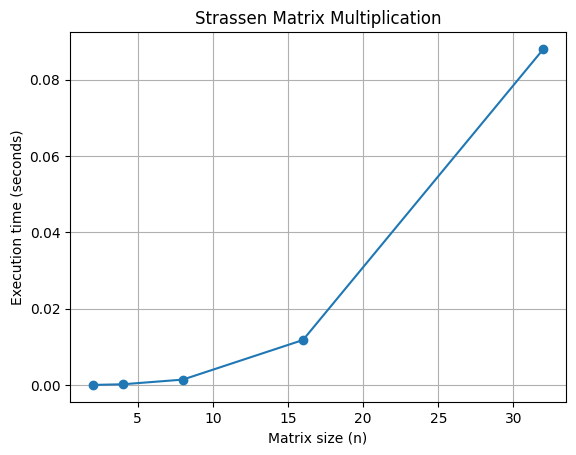

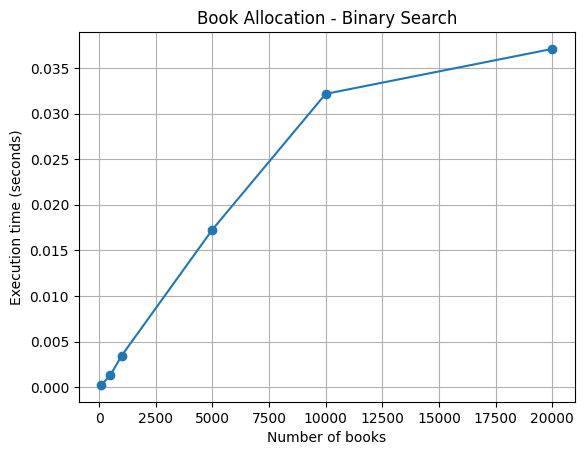

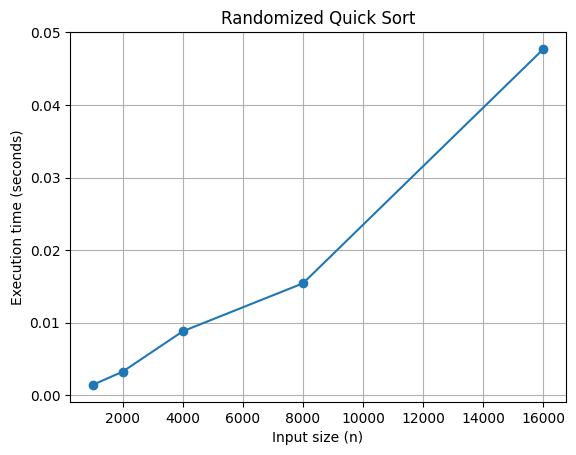

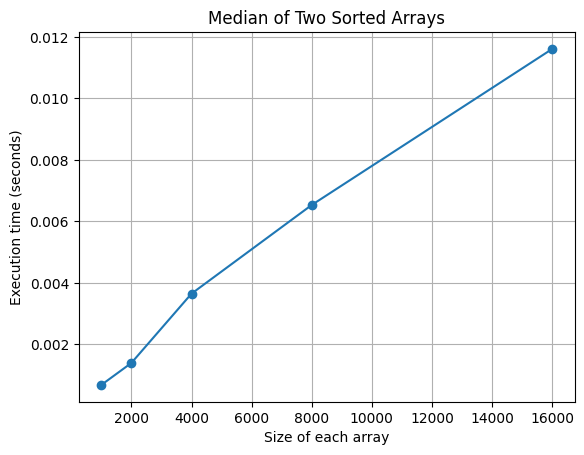

In [1]:
import random
import time
import matplotlib.pyplot as plt
import numpy as np

# DIVIDE AND CONQUER : MATRICES AND SELECTION

# Matrix multiplication - Brute force
def matrix_multiply(A, B):

    n = len(A)
    m = len(B[0])
    p = len(B)

    C = [[0 for j in range(m)] for i in range(n)]

    for i in range(n):
        for j in range(m):
            for k in range(p):
                C[i][j] += A[i][k] * B[k][j]

    return C


sizes = [2, 4, 8, 16, 24, 32]
times = []

for n in sizes:

    A = [[random.randint(1, 10) for _ in range(n)]
         for _ in range(n)]

    B = [[random.randint(1, 10) for _ in range(n)]
         for _ in range(n)]

    start = time.perf_counter()
    matrix_multiply(A, B)
    end = time.perf_counter()

    times.append(end - start)

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel("Matrix size (n)")
plt.ylabel("Execution time (seconds)")
plt.title("Brute Force Matrix Multiplication")
plt.grid(True)
plt.show()



# Strassen matrix multiplication
def add_matrix(A, B):

    n = len(A)

    return [
        [A[i][j] + B[i][j] for j in range(n)]
        for i in range(n)
    ]


def subtract_matrix(A, B):

    n = len(A)

    return [
        [A[i][j] - B[i][j] for j in range(n)]
        for i in range(n)
    ]


def strassen(A, B):

    n = len(A)

    if n == 1:
        return [[A[0][0] * B[0][0]]]

    mid = n // 2

    A11 = [row[:mid] for row in A[:mid]]
    A12 = [row[mid:] for row in A[:mid]]
    A21 = [row[:mid] for row in A[mid:]]
    A22 = [row[mid:] for row in A[mid:]]

    B11 = [row[:mid] for row in B[:mid]]
    B12 = [row[mid:] for row in B[:mid]]
    B21 = [row[:mid] for row in B[mid:]]
    B22 = [row[mid:] for row in B[mid:]]

    M1 = strassen(
        add_matrix(A11, A22),
        add_matrix(B11, B22)
    )

    M2 = strassen(
        add_matrix(A21, A22),
        B11
    )

    M3 = strassen(
        A11,
        subtract_matrix(B12, B22)
    )

    M4 = strassen(
        A22,
        subtract_matrix(B21, B11)
    )

    M5 = strassen(
        add_matrix(A11, A12),
        B22
    )

    M6 = strassen(
        subtract_matrix(A21, A11),
        add_matrix(B11, B12)
    )

    M7 = strassen(
        subtract_matrix(A12, A22),
        add_matrix(B21, B22)
    )

    C11 = add_matrix(
        subtract_matrix(
            add_matrix(M1, M4),
            M5
        ),
        M7
    )

    C12 = add_matrix(M3, M5)

    C21 = add_matrix(M2, M4)

    C22 = add_matrix(
        subtract_matrix(
            add_matrix(M1, M3),
            M2
        ),
        M6
    )

    C = []

    for i in range(mid):
        C.append(C11[i] + C12[i])

    for i in range(mid):
        C.append(C21[i] + C22[i])

    return C


sizes = [2, 4, 8, 16, 32]
times = []

for n in sizes:

    A = [[random.randint(1, 10) for _ in range(n)]
         for _ in range(n)]

    B = [[random.randint(1, 10) for _ in range(n)]
         for _ in range(n)]

    start = time.perf_counter()
    strassen(A, B)
    end = time.perf_counter()

    times.append(end - start)

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel("Matrix size (n)")
plt.ylabel("Execution time (seconds)")
plt.title("Strassen Matrix Multiplication")
plt.grid(True)
plt.show()


# Binary search - Book allocation
def can_allocate(books, students, max_pages):

    count = 1
    pages = 0

    for book in books:

        if pages + book <= max_pages:
            pages += book

        else:
            count += 1
            pages = book

    return count <= students


def allocate_pages(books, students):

    low = max(books)
    high = sum(books)

    answer = high

    while low <= high:

        mid = (low + high) // 2

        if can_allocate(books, students, mid):

            answer = mid
            high = mid - 1

        else:
            low = mid + 1

    return answer


sizes = [100, 500, 1000, 5000, 10000, 20000]
times = []

for n in sizes:

    books = [random.randint(10, 1000) for _ in range(n)]
    students = 10

    start = time.perf_counter()
    allocate_pages(books, students)
    end = time.perf_counter()

    times.append(end - start)

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel("Number of books")
plt.ylabel("Execution time (seconds)")
plt.title("Book Allocation - Binary Search")
plt.grid(True)
plt.show()


# Randomized quick sort
def randomized_quick_sort(arr):

    if len(arr) <= 1:
        return arr

    pivot = random.choice(arr)

    left = []
    middle = []
    right = []

    for x in arr:

        if x < pivot:
            left.append(x)

        elif x == pivot:
            middle.append(x)

        else:
            right.append(x)

    return (
        randomized_quick_sort(left)
        + middle
        + randomized_quick_sort(right)
    )


sizes = [1000, 2000, 4000, 8000, 16000]
times = []

for n in sizes:

    arr = random.sample(range(n * 2), n)

    start = time.perf_counter()
    randomized_quick_sort(arr)
    end = time.perf_counter()

    times.append(end - start)

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel("Input size (n)")
plt.ylabel("Execution time (seconds)")
plt.title("Randomized Quick Sort")
plt.grid(True)
plt.show()


# Median of two sorted arrays
def median_two_arrays(A, B):

    C = []

    i = 0
    j = 0

    while i < len(A) and j < len(B):

        if A[i] < B[j]:
            C.append(A[i])
            i += 1

        else:
            C.append(B[j])
            j += 1

    while i < len(A):
        C.append(A[i])
        i += 1

    while j < len(B):
        C.append(B[j])
        j += 1

    n = len(C)

    if n % 2 == 0:
        return (C[n // 2 - 1] + C[n // 2]) / 2

    else:
        return C[n // 2]


sizes = [1000, 2000, 4000, 8000, 16000]
times = []

for n in sizes:

    A = list(range(0, 2 * n, 2))
    B = list(range(1, 2 * n, 2))

    start = time.perf_counter()
    median_two_arrays(A, B)
    end = time.perf_counter()

    times.append(end - start)

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel("Size of each array")
plt.ylabel("Execution time (seconds)")
plt.title("Median of Two Sorted Arrays")
plt.grid(True)
plt.show()

